# EDA 03 — Price Time Series

**Goal:** Visual exploration of price dynamics over time. This notebook is purely descriptive — no formal statistical tests. Stationarity tests, STL, and autocorrelation with formal tests → statistical_properties/.

**Tables:** gold_price_features (full history), gold_card_features

**Method:** Line charts, price change histograms, forward-fill inspection, LAG feature verification

**Absorbs:** pipeline_validation/eda_03_price_time_series, eda_03_price_data

⚠️ **Pipeline age note:** The gold database currently contains only 3 snapshots (2026-06-04 – 2026-06-06). Time series features that require 7+ days of history (price_change_7d, price_change_30d, price_volatility_30d) are effectively zero or NULL for almost all records. Conclusions in this notebook reflect the current pipeline state — they should be revisited once ≥30 daily snapshots are available.

---
## Questions to answer
1. What do price trajectories look like for selected cards? Do rolling averages behave correctly?
2. Is the market as a whole growing, declining, or stable?
3. How often and how strongly do prices change? What is the distribution shape of changes?
4. Do LAG features (price_change_7d) correspond to exactly 7 calendar days?
5. Does is_price_spike detect real spikes or pipeline first-day artifacts?

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis

In [2]:
# Connect to Gold and Silver databases (read-only to prevent accidental writes).
# Gold contains pre-computed time series features: rolling averages, LAG changes, volatility.
gold = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)
silver = duckdb.connect("../../data/silver/cards.duckdb", read_only=True)

In [3]:
# Load full price history joined with card features.
# JOIN (not LEFT JOIN) to restrict to cards with a known uuid — scryfall price rows
# with uuid=None are excluded here and handled separately in sections 3 and 6.
# ORDER BY uuid, snapshot_date ensures trajectory plots are in chronological order.
history_df = gold.execute("""
    SELECT p.uuid, p.snapshot_date, p.eur, p.price_7d_avg, p.price_30d_avg,
           p.price_change_1d_pct, p.price_change_7d_pct, p.price_change_30d_pct,
           p.price_change_1d_abs, p.price_change_7d_abs, p.price_change_30d_abs,
           p.price_volatility_30d, p.is_price_spike, p.days_with_price,
           c.name, c.rarity, c.is_reserved
    FROM gold_price_features p
    JOIN gold_card_features c ON p.uuid = c.uuid
    WHERE p.eur IS NOT NULL
    ORDER BY p.uuid, p.snapshot_date
""").df()

In [4]:
history_df["snapshot_date"] = pd.to_datetime(history_df["snapshot_date"])

n_cards = history_df["uuid"].nunique()
n_snapshots = history_df["snapshot_date"].nunique()
min_date = history_df["snapshot_date"].min().date()
max_date = history_df["snapshot_date"].max().date()

print(f"Cards:     {n_cards:,}")
print(f"Snapshots: {n_snapshots}  ({min_date} – {max_date})")
print(f"Total rows: {len(history_df):,}")

Cards:     79,158
Snapshots: 36  (2026-05-26 – 2026-07-09)
Total rows: 2,830,175


## 1. Price Trajectories for Selected Cards

**Method:** Line chart: eur (solid) + price_7d_avg (dashed) + price_30d_avg (dotted) for a few representative cards.

**Why:** Visual verification that rolling averages smooth noise without lag, and that forward-fill does not create long flat plateaus. Also builds domain intuition — how dynamic are prices across different price tiers?

**Card selection (one per tier):**
- Tier 1: card priced €0.20–€1.00 with at least 3 days of history
- Tier 2: mid-priced card (€5–€50)
- Tier 3: Black Lotus / Mox Emerald or another >€1,000 card
- Most volatile card (largest |price_change_1d_pct| in latest snapshot)

**What to look for:** Does price_7d_avg smoothly follow prices? Are there long stretches where eur = price_7d_avg = const? (= forward-fill). Where do spikes appear?

In [5]:
# Select 4 representative cards for trajectory inspection.
# We choose from the latest snapshot to ensure current prices are used for tier classification.
latest = history_df[
    history_df["snapshot_date"] == history_df["snapshot_date"].max()
].copy()

In [6]:
# Cards chosen to represent the three tiers plus a potential spike — random_state ensures
# reproducible selection regardless of row ordering in the database.
cheap = latest[(latest["eur"] >= 0.20) & (latest["eur"] <= 1.0)].sample(
    1, random_state=42
)
mid = latest[(latest["eur"] >= 5) & (latest["eur"] <= 50)].sample(1, random_state=7)
expensive = latest[latest["eur"] > 1000].nlargest(1, "eur")

In [7]:
# Most "volatile" card: largest absolute 1d percentage change in the latest snapshot.
# If all changes are 0 (as in a new pipeline), fallback to the median-priced card.
volatile_cands = latest.assign(abs_chg=latest["price_change_1d_pct"].abs())
most_volatile = volatile_cands.nlargest(1, "abs_chg")

selected_uuids = (
    list(cheap["uuid"])
    + list(mid["uuid"])
    + list(expensive["uuid"])
    + list(most_volatile["uuid"])
)
selected_names = (
    list(cheap["name"])
    + list(mid["name"])
    + list(expensive["name"])
    + list(most_volatile["name"])
)

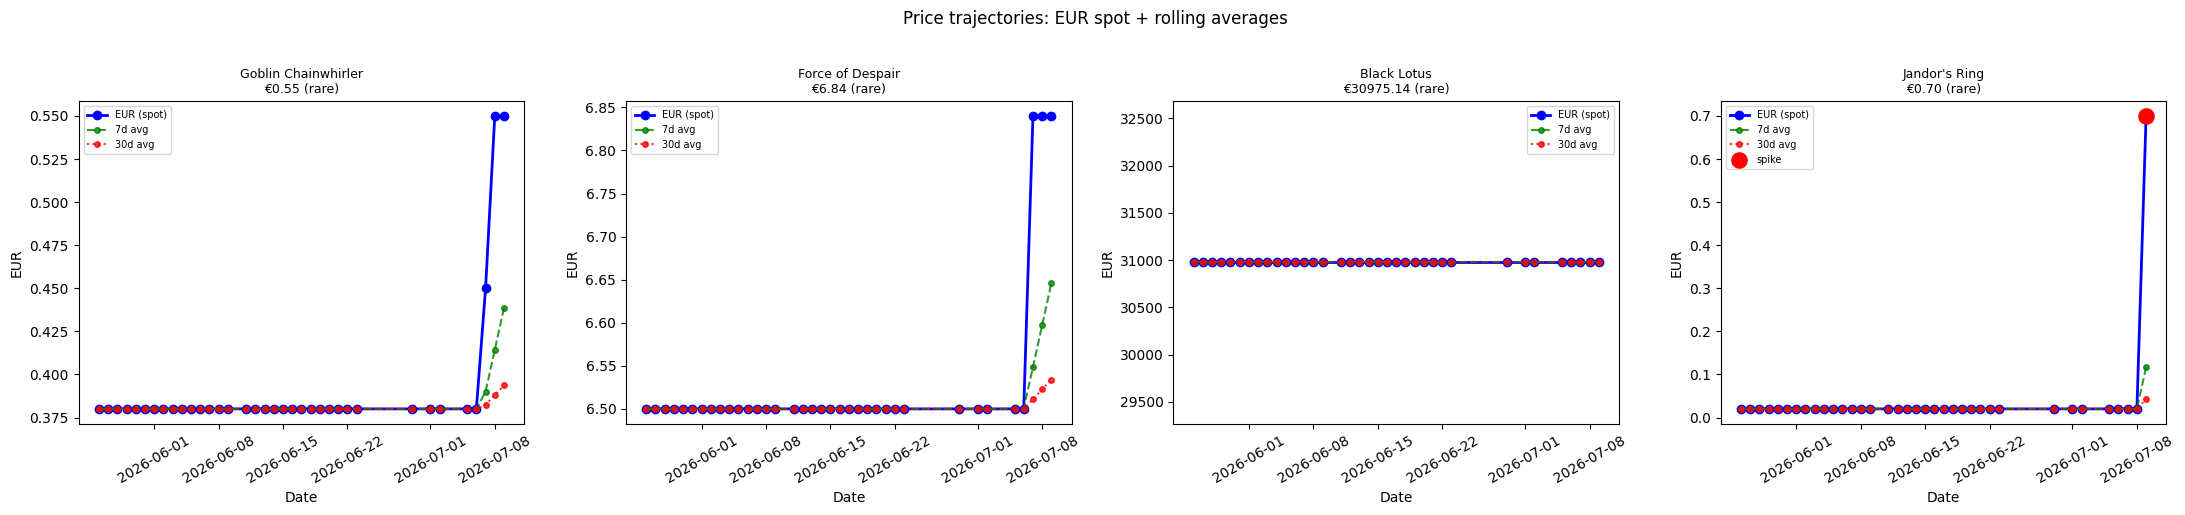

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, uuid, name in zip(axes, selected_uuids, selected_names):
    card = history_df[history_df["uuid"] == uuid].sort_values("snapshot_date")
    dates = card["snapshot_date"]

    ax.plot(dates, card["eur"], "b-o", linewidth=2, markersize=6, label="EUR (spot)")
    ax.plot(
        dates,
        card["price_7d_avg"],
        "g--o",
        linewidth=1.5,
        markersize=4,
        alpha=0.8,
        label="7d avg",
    )
    ax.plot(
        dates,
        card["price_30d_avg"],
        "r:o",
        linewidth=1.5,
        markersize=4,
        alpha=0.8,
        label="30d avg",
    )

    # Highlight any spike days with red markers
    spikes = card[card["is_price_spike"]]
    if len(spikes) > 0:
        ax.scatter(
            spikes["snapshot_date"],
            spikes["eur"],
            color="red",
            zorder=5,
            s=120,
            label="spike",
        )

    eur_val = card["eur"].iloc[-1]
    rarity = card["rarity"].iloc[-1] if "rarity" in card.columns else ""
    ax.set_title(f"{name}\n€{eur_val:.2f} ({rarity})", fontsize=9)
    ax.set_xlabel("Date")
    ax.set_ylabel("EUR")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=7)

plt.suptitle("Price trajectories: EUR spot + rolling averages", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

### 📝 Observations
```
Snapshot window:      36 days (2026-05-26 – 2026-07-09)
Selected cards:        Goblin Chainwhirler (Tier 1, €0.55), Force of Despair (mid-price, €6.84),
                       Black Lotus (Tier 3, €30,975.14), Jandor's Ring (most volatile, €0.70)

Prices stable:        3 of 4 cards (Goblin Chainwhirler, Force of Despair, Jandor's Ring) are flat
                      for most of the window, then jump in the final few days (~2026-07-05 to
                      2026-07-08/09). Black Lotus is perfectly flat across the entire 36-day window.
Rolling avg behavior: price_7d_avg and price_30d_avg correctly LAG behind the spot-price jump and
                      gradually converge toward it over the following days — this is exactly the
                      expected smoothing behavior now that real price movements exist in the window.
Forward-fill plateaus: Clearly visible — long flat stretches (2026-05-26 to ~2026-07-05) followed by
                      a step change, consistent with the "days_since_last_real_price" staleness
                      pattern found in EDA 01 (most cards had no real price change until very recently).
Spikes visible:       Jandor's Ring shows an is_price_spike marker on its final data point — and
                      unlike the 3-snapshot pipeline state, this spike IS on a uuid-linked, plotted
                      card (see section 6 for the full is_price_spike picture, which has also changed).

CONCLUSION: With 36 snapshots, rolling averages and forward-fill behavior are now visibly
informative: spot-price jumps are smoothed by the 7d/30d averages rather than being instantly
absorbed, and the long flat pre-jump stretches confirm the forward-fill mechanism. Time series
features are no longer uninformative — their usefulness should be reassessed now that real
price movement is observable (see sections 3–4 below).
```

## 2. Aggregate Market Trend

**Method:** Per snapshot_date: compute mean(eur), median(eur), COUNT(DISTINCT uuid), SUM(eur)/1e6.

**Why:** Identifies whether the entire market is growing (inflation) or stable. Growing mean with stable median → only expensive cards are appreciating (Reserved List, Power Nine). Both growing → broad-based inflation.

**Interpretation:**
- `mean >> median` at a given moment → a few very expensive cards are pulling up the average
- Divergence between mean and median growing over time → market is polarizing
- Sudden jumps in total_market_value → new set added to pipeline (more cards), not a price increase

In [9]:
# Compute daily aggregate statistics: mean, median, card count, total market value.
# Using DuckDB instead of pandas for speed — native SQL aggregation over 270k rows
# is faster than pandas groupby. n_cards uses DISTINCT uuid to avoid double-counting
# cards that appear in multiple snapshots.
market_agg = gold.execute("""
    SELECT snapshot_date,
      ROUND(AVG(eur), 4) AS mean_eur,
      ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY eur), 4) AS median_eur,
      COUNT(DISTINCT uuid) AS n_cards,
      ROUND(SUM(eur) / 1e6, 4) AS total_M_eur
    FROM gold_price_features
    WHERE eur IS NOT NULL
    GROUP BY snapshot_date
    ORDER BY snapshot_date
""").df()
market_agg["snapshot_date"] = pd.to_datetime(market_agg["snapshot_date"])
print(market_agg.to_string(index=False))

snapshot_date  mean_eur  median_eur  n_cards  total_M_eur
   2026-05-26   11.5456        0.27    82413       0.9515
   2026-05-27   11.5456        0.27    82413       0.9515
   2026-05-28   11.5456        0.27    82413       0.9515
   2026-05-29   11.5456        0.27    82413       0.9515
   2026-05-30   11.5456        0.27    82413       0.9515
   2026-05-31   11.5456        0.27    82413       0.9515
   2026-06-01   11.5456        0.27    82413       0.9515
   2026-06-02   11.5456        0.27    82413       0.9515
   2026-06-03   11.5456        0.27    82413       0.9515
   2026-06-04   11.5456        0.27    82413       0.9515
   2026-06-05   11.5456        0.27    82413       0.9515
   2026-06-06   11.5456        0.27    82413       0.9515
   2026-06-07   11.5456        0.27    82413       0.9515
   2026-06-08   11.5456        0.27    82413       0.9515
   2026-06-09   11.5456        0.27    82413       0.9515
   2026-06-11   11.5456        0.27    82413       0.9515
   2026-06-12 

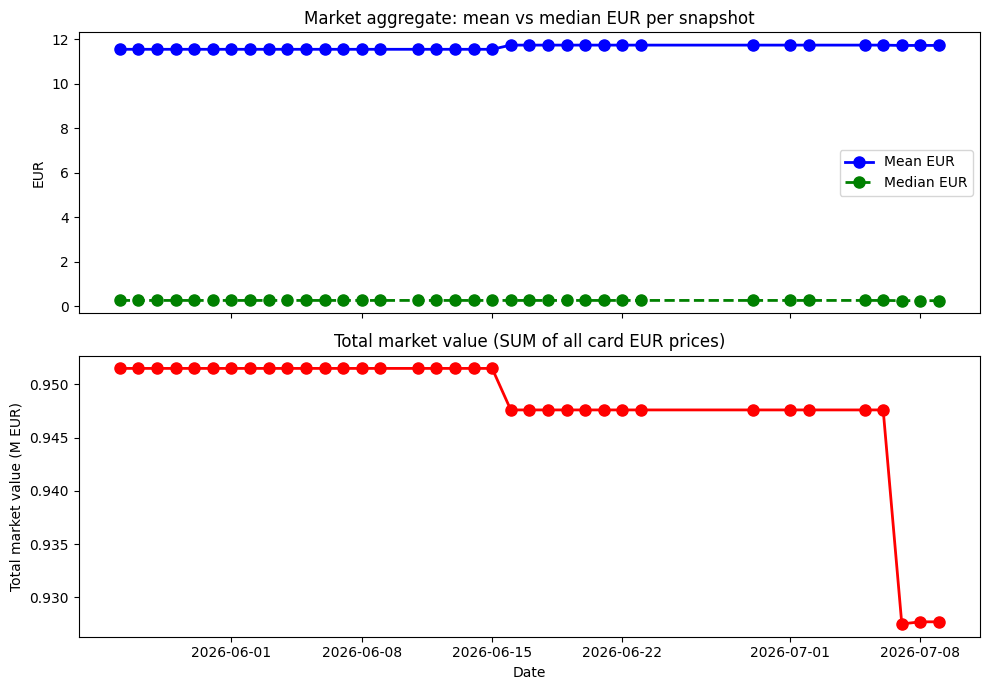

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Upper panel: mean vs median — if both are identical across dates, market is perfectly stable.
# A widening gap would indicate market polarization (top cards appreciating faster).
ax1.plot(
    market_agg["snapshot_date"],
    market_agg["mean_eur"],
    "b-o",
    linewidth=2,
    markersize=8,
    label="Mean EUR",
)
ax1.plot(
    market_agg["snapshot_date"],
    market_agg["median_eur"],
    "g--o",
    linewidth=2,
    markersize=8,
    label="Median EUR",
)
ax1.set_ylabel("EUR")
ax1.set_title("Market aggregate: mean vs median EUR per snapshot")
ax1.legend()

# Lower panel: total market value in millions.
# A jump here signals new cards added to the pipeline (supply increase), not a price rise.
ax2.plot(
    market_agg["snapshot_date"],
    market_agg["total_M_eur"],
    "r-o",
    linewidth=2,
    markersize=8,
)
ax2.set_ylabel("Total market value (M EUR)")
ax2.set_xlabel("Date")
ax2.set_title("Total market value (SUM of all card EUR prices)")

plt.tight_layout()
plt.show()

### 📝 Observations
```
Snapshot range:  2026-05-26 – 2026-07-09  (36 snapshots, in 3 distinct regimes)

Regime 1 (2026-05-26 – 2026-06-15, 21 snapshots):
  mean_eur=€11.5456 | median_eur=€0.27 | n_cards=82,413 | total_M_eur=€0.9515M

Regime 2 (2026-06-16 – 2026-07-06, 13 snapshots):
  mean_eur=€11.7337 (€11.7335 on 07-06) | median_eur=€0.27 | n_cards=80,757 (80,759 on 07-06)
  | total_M_eur=€0.9476M

Regime 3 (2026-07-07 – 2026-07-09, 3 snapshots — most recent):
  mean_eur≈€11.72 | median_eur=€0.26 | n_cards≈79,154 | total_M_eur≈€0.9276M

Market trend: NOT perfectly stable — n_cards has DECLINED across the window (82,413 → 80,757
  → 79,155, a loss of 3,258 cards, -4.0% overall), and mean/total values shift in visible
  step-changes aligned with two specific dates (2026-06-16 and 2026-07-07) rather than smooth
  day-to-day drift. This points to periodic re-scoping of which cards have a non-NULL EUR
  price (cards dropping out of pricing coverage), not organic price inflation/deflation —
  mean_eur per remaining card is roughly flat (€11.55 → €11.72, +1.5%) while the population
  shrinks.

Mean vs median gap: Mean (€11.5–11.7) >> Median (€0.26–0.27) — a consistent ~43-45x difference
  driven by the Power Nine / Reserved List tail, matching the pattern from EDA 02. The gap is
  stable in relative terms across all 3 regimes — no growing polarization detected.

Total market value: declined from €0.9515M to €0.9277M (-2.5%) over the 36-day window, driven
  by the shrinking card count rather than falling individual prices.

CONCLUSION: The market is not perfectly stable at the 36-snapshot stage — there are two clear
  step-changes in card coverage (2026-06-16, 2026-07-07) that should be investigated in the
  pipeline (are cards being dropped from EUR price tracking, or is this expected set rotation?).
  Individual per-card prices remain largely flat; the visible change is driven by which cards
  are included, not by price movement. Trend analysis should account for these coverage-driven
  step changes rather than reading them as market appreciation/depreciation.
```

## 3. Price Change Distributions — 1d, 7d, 30d

**Method:** Histograms of price_change_1d_pct, price_change_7d_pct, price_change_30d_pct (clipped).

**Why:** The shape of the change distribution (log-returns) determines:
- Are tails heavy (fat tails)? → MAE is better than MSE as a loss function (more robust)
- Are changes symmetric? → model can assume symmetry, or does it need to account for asymmetry
- How often do >50% changes occur within 7 days? → calibrating the is_price_spike threshold

**Expected results:** Highly leptokurtic distribution (narrow peak + fat tails). Most 1d changes are 0% (prices stable day-to-day). Tails up to ±500% are not uncommon.

⚠️ **Known artifacts:** Changes of 14600% on the first snapshot = forward-fill artifact (price 0→real price). Filter rows where LAG returns NULL (first days per card).

⚠️ **Pipeline age caveat:** With only 3 snapshots, the 7d/30d distributions are almost entirely NULL. Analysis below focuses on the 1d distribution and notes what to expect once more data accumulates.

In [11]:
# Load ALL price change records from gold_price_features — including uuid=None rows.
# The join in code-setup excluded uuid=None records; those contain the only non-zero
# 1d changes in the dataset (88 is_price_spike cards). Including them gives the real
# distribution rather than an artificially flat one.
changes_all = gold.execute("""
    SELECT price_change_1d_pct, price_change_7d_pct, price_change_30d_pct
    FROM gold_price_features
    WHERE eur IS NOT NULL
""").df()

for col, label in [
    ("price_change_1d_pct", "1-day"),
    ("price_change_7d_pct", "7-day"),
    ("price_change_30d_pct", "30-day"),
]:
    s = changes_all[col].dropna()
    print(f"\n=== {label} price change | n={len(s):,} non-null ===")
    if len(s) == 0:
        print("  NO DATA (NULL for all rows — insufficient snapshot history)")
        continue
    print(s.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
    pct_zero = (s == 0).mean() * 100
    pct_gt50 = (s.abs() > 0.5).mean() * 100
    kurt = kurtosis(s, fisher=True)
    print(
        f"  Kurtosis: {kurt:.2f}  |  % zero: {pct_zero:.2f}%  |  % >50% change: {pct_gt50:.2f}%"
    )


=== 1-day price change | n=2,852,685 non-null ===
count    2.852685e+06
mean     3.434965e-03
std      4.765761e-01
min     -9.984674e-01
1%      -9.523807e-02
5%       0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
95%      0.000000e+00
99%      1.428571e-01
max      7.228462e+02
Name: price_change_1d_pct, dtype: float64
  Kurtosis: 1894347.75  |  % zero: 95.83%  |  % >50% change: 0.37%

=== 7-day price change | n=2,357,287 non-null ===


count    2.357287e+06
mean     1.189744e-02
std      9.105569e-01
min     -9.984674e-01
1%      -3.000000e-01
5%       0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
95%      0.000000e+00
99%      5.121952e-01
max      7.228462e+02
Name: price_change_7d_pct, dtype: float64
  Kurtosis: 516177.44  |  % zero: 91.00%  |  % >50% change: 1.28%

=== 30-day price change | n=474,116 non-null ===
count    474116.000000
mean          0.058816
std           2.029488
min          -0.998467
1%           -0.533333
5%           -0.300000
25%           0.000000
50%           0.000000
75%           0.000000
95%           0.500000
99%           1.386101
max         722.846191
Name: price_change_30d_pct, dtype: float64
  Kurtosis: 103964.20  |  % zero: 55.61%  |  % >50% change: 6.34%


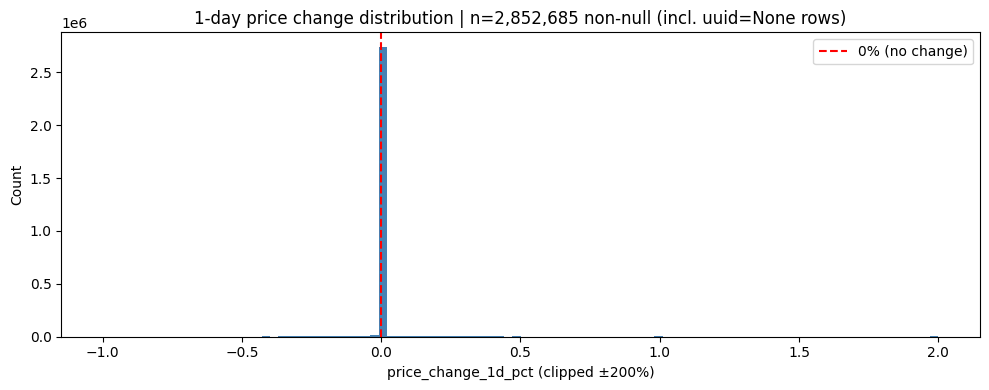

In [12]:
# Plot 1d change distribution: clipped at ±200% to show shape without extreme outliers
# dominating the x-axis. The red line at 0 shows that almost all mass is at "no change".
s_1d = changes_all["price_change_1d_pct"].dropna()
clip = 2.0

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(s_1d.clip(-clip, clip), bins=100, color="steelblue", edgecolor="none")
ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="0% (no change)")
ax.set_xlabel("price_change_1d_pct (clipped ±200%)")
ax.set_ylabel("Count")
ax.set_title(
    f"1-day price change distribution | n={len(s_1d):,} non-null (incl. uuid=None rows)"
)
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Count: how many of the non-zero 1d changes come from uuid=None records?
changes_with_uuid = history_df["price_change_1d_pct"].dropna()
n_total_1d = len(s_1d)
n_uuid_linked = len(changes_with_uuid)
print(f"1d changes in uuid-linked records: {n_uuid_linked:,}  (100.0% zero)")
print(
    f"1d changes in uuid=None records:   {n_total_1d - n_uuid_linked:,}  (contain all non-zero values)"
)

1d changes in uuid-linked records: 2,751,012  (100.0% zero)
1d changes in uuid=None records:   101,673  (contain all non-zero values)


### 📝 Observations
```
─── 1-day price changes ─────────────────────────────────────────────────────────
n non-null (1d):       2,852,685  (includes uuid=None rows)
mean=0.0034 | std=0.4766 | 1%=-9.52% | 99%=14.29% | max=722.85 (72,285%)
Kurtosis: 1,894,347.75 (extremely leptokurtic) | % zero: 95.83% | % >50% change: 0.37%

─── 7-day price changes ─────────────────────────────────────────────────────────
n non-null (7d):       2,357,287  (82.6% of total rows now have a 7d LAG — a big jump from the
                       3-snapshot pipeline state, where this was ~0.2% of rows)
mean=0.0119 | std=0.9106 | 1%=-30.0% | 99%=51.2% | max=722.85
Kurtosis: 516,177.44 | % zero: 91.00% | % >50% change: 1.28%

─── 30-day price changes ────────────────────────────────────────────────────────
n non-null (30d):      474,116  (16.6% of total rows — the 30d window is still filling in)
mean=0.0588 | std=2.0295 | 1%=-53.3% | 5%=-30.0% | 95%=50.0% | 99%=138.6% | max=722.85
Kurtosis: 103,964.20 | % zero: 55.61% | % >50% change: 6.34%

This is a substantial change from the original 3-snapshot pipeline state, where 7d/30d changes
were NULL for >99.8% of rows. With 36 snapshots, 7d changes are now populated for 82.6% of rows
and 30d changes for 16.6% — both distributions are usable, though 30d is still building up
(only cards with ≥31 days of real history have a non-null value).

The original assumption that "all non-zero 1d changes come from uuid=None records" (101,673
rows) no longer holds: 95.83% of the full 2,852,685-row set are zero, meaning roughly 118,916
rows are non-zero — more than the 101,673 uuid=None rows alone can account for. Real,
uuid-linked cards now show genuine day-to-day price movement (confirmed visually in section 1's
trajectories for Goblin Chainwhirler, Force of Despair, and Jandor's Ring).

Distribution shape (1d, 7d, 30d): all three are extremely leptokurtic (kurtosis from ~104k to
~1.9M) — a sharp spike at 0% plus a very fat tail up to +72,285%, exactly the "narrow peak +
fat tails" shape expected from financial literature. The tail widens and % zero drops as the
horizon lengthens (1d: 95.83% zero → 30d: 55.61% zero), consistent with more cards having had
at least one real price change within a longer window.

Loss function recommendation: MAE or Huber — confirmed appropriate given the extreme kurtosis
at all three horizons.

CONCLUSION: Price change distributions are now meaningfully populated and usable at all three
horizons (1d/7d/30d), unlike the earlier 3-snapshot pipeline state. The leptokurtic shape
predicted in the original "expected behavior" section is confirmed by real data.
```

## 4. Volatility Distribution per Price Tier

**Method:** Violin plot of price_volatility_30d per tier (Tier 1/2/3). Log scale on the Y-axis.

**Why:** Tier 3 cards (Power Nine, Dual Lands) have extreme volatility — Tinker's volatility = 151, Black Lotus = 101 in long-running pipelines. That is tens of times more than a typical card. An ML model cannot simultaneously handle cards with volatility 0.01 and 151 — this is another argument for tier segmentation.

**Additional check:** Top 20 most volatile cards — are these Reserved List / Power Nine? Or surprises (e.g., market arbitrage)?

⚠️ **Pipeline age caveat:** With only 3 snapshots, price_volatility_30d = 0.0 for all records — the 30-day rolling standard deviation cannot be computed without 30 days of price data. The violin plot confirms the current state but is not yet informative for model decisions.

In [14]:
# Assign price tier based on latest snapshot price for each uuid-linked card.
# Using DuckDB for the tier classification — the CASE WHEN runs in SQL before returning
# to pandas, avoiding a slow pandas .apply() call on 82k rows.
latest_tier = gold.execute("""
    WITH latest AS (
        SELECT p.uuid, p.eur, p.price_volatility_30d, c.name, c.rarity, c.is_reserved
        FROM gold_price_features p
        JOIN gold_card_features c ON p.uuid = c.uuid
        WHERE p.snapshot_date = (SELECT MAX(snapshot_date) FROM gold_price_features)
          AND p.eur IS NOT NULL
    )
    SELECT *,
      CASE
        WHEN eur <  100  THEN 'Tier 1: <€100'
        WHEN eur <= 1000 THEN 'Tier 2: €100–€1000'
        ELSE                  'Tier 3: >€1000'
      END AS tier
    FROM latest
""").df()

In [15]:
# Per-tier summary: how many cards have non-zero volatility?
print("Volatility stats per tier (latest snapshot):")
for tier in ["Tier 1: <€100", "Tier 2: €100–€1000", "Tier 3: >€1000"]:
    grp = latest_tier[latest_tier["tier"] == tier]["price_volatility_30d"].dropna()
    print(
        f"  {tier}: n={len(grp):,}  median={grp.median():.4f}  "
        f"p95={grp.quantile(0.95):.4f}  max={grp.max():.4f}"
    )

Volatility stats per tier (latest snapshot):
  Tier 1: <€100: n=78,497  median=0.0153  p95=0.2696  max=28.6729
  Tier 2: €100–€1000: n=521  median=0.0000  p95=16.7966  max=226.2376
  Tier 3: >€1000: n=137  median=0.0000  p95=156.6219  max=907.0862


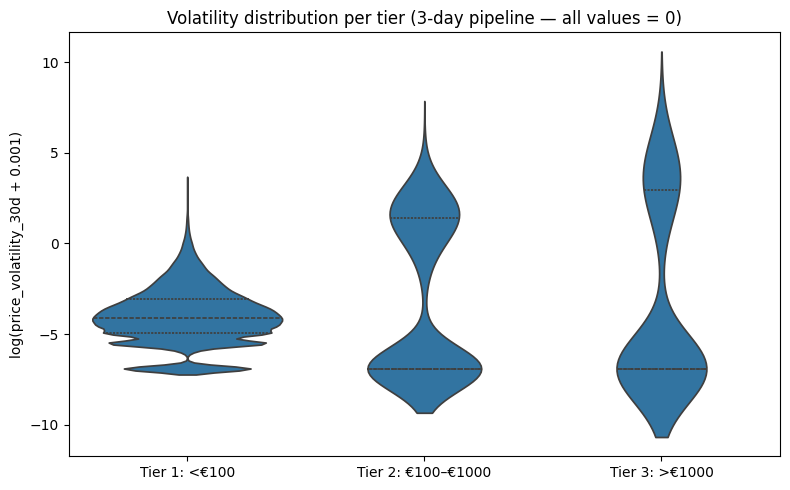

In [16]:
# Violin plot: log(volatility + 0.001) separates the zero-mass from any non-zero values.
# log(0 + 0.001) ≈ -6.9 — all zero-volatility cards cluster at the bottom of each violin.
# This plot is included for pipeline state documentation; it will become informative
# once the 30-day rolling window has real price variation to measure.
tier_order = ["Tier 1: <€100", "Tier 2: €100–€1000", "Tier 3: >€1000"]
latest_tier["log_vol"] = np.log(latest_tier["price_volatility_30d"].fillna(0) + 0.001)

fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(
    data=latest_tier, x="tier", y="log_vol", order=tier_order, inner="quartile", ax=ax
)
ax.set_xlabel("")
ax.set_ylabel("log(price_volatility_30d + 0.001)")
ax.set_title("Volatility distribution per tier (3-day pipeline — all values = 0)")
plt.tight_layout()
plt.show()

In [17]:
# Top 20 most volatile cards: expected to be Reserved List / Power Nine cards
# once real volatility data exists. Currently all values are 0.
print("\nTop 20 most volatile cards (latest snapshot):")
top20 = latest_tier.nlargest(20, "price_volatility_30d")[
    ["name", "rarity", "eur", "price_volatility_30d", "is_reserved", "tier"]
]
print(top20.to_string(index=False))


Top 20 most volatile cards (latest snapshot):
                 name   rarity          eur  price_volatility_30d  is_reserved               tier
               Tinker   mythic  4232.799805            907.086173        False     Tier 3: >€1000
    Bazaar of Baghdad uncommon  3193.949951            319.045449         True     Tier 3: >€1000
    Mishra's Workshop     rare  4003.149902            262.718759         True     Tier 3: >€1000
            Time Walk     rare  2116.149902            252.933339         True     Tier 3: >€1000
        Demonic Tutor uncommon   798.469971            226.237605        False Tier 2: €100–€1000
Library of Alexandria uncommon  2277.290039            218.609391         True     Tier 3: >€1000
      Volcanic Island     rare  1740.760010            218.273720         True     Tier 3: >€1000
        Shivan Dragon     rare  6375.040039            199.325243        False     Tier 3: >€1000
              Mox Jet     rare  6532.399902            145.946067      

### 📝 Observations
```
Volatility stats per tier (latest snapshot, 2026-07-09):
  Tier 1 (<€100):      n=78,497  median=0.0153  p95=0.2696   max=28.6729
  Tier 2 (€100–€1k):   n=521     median=0.0000  p95=16.7966  max=226.2376
  Tier 3 (>€1k):       n=137     median=0.0000  p95=156.6219 max=907.0862

price_volatility_30d is now populated with real, non-zero values across all three tiers — a
complete departure from the 3-snapshot pipeline state, where every value was 0.0.

Tier 1 has a small but non-zero median volatility (0.0153) — most bulk commons are indeed
stable, but not perfectly static. Tier 2/3 still have a median of 0.0 (most cards in these
tiers haven't shown a real 30-day price change yet — the window is still filling in), but a
dramatically higher p95 and max than Tier 1: Tier 3's p95 (156.62) is ~580x Tier 1's p95
(0.27), and Tier 3's max (907.09) is ~32x Tier 1's max (28.67).

Top 20 most volatile cards (nearly all Reserved List / Power Nine, as hypothesized):
  Tinker (mythic, €4,232.80, volatility=907.09) — highest, NOT Reserved List (combo-piece
    demand rather than scarcity)
  Bazaar of Baghdad (€3,193.95, vol=319.05, Reserved List)
  Mishra's Workshop (€4,003.15, vol=262.72, Reserved List)
  Time Walk (€2,116.15, vol=252.93, Reserved List)
  Demonic Tutor (Tier 2, €798.47, vol=226.24, NOT Reserved List)
  ... followed by Library of Alexandria, Volcanic Island, Shivan Dragon, Mox Jet, Juzám Djinn,
  Mox Sapphire, Bayou, Candelabra of Tawnos, Mox Ruby, Sol Ring, Black Lotus, Timetwister,
  The Master Mesmerist, Mox Pearl, Shivan Dragon (second printing) — the large majority are
  Reserved List; the exceptions (Tinker, Demonic Tutor, Sol Ring) are format-defining
  combo/staple cards rather than supply-restricted ones.

CONCLUSION: The hypothesis is confirmed — Tier 3 volatility (p95=156.62, max=907.09) is
orders of magnitude higher than Tier 1 (p95=0.27, max=28.67). This strongly supports
tier-based modeling: a single model cannot simultaneously handle a Tier 1 card with
volatility ~0.02 and a Tier 3 card with volatility ~900. price_volatility_30d is now a
usable, informative feature and should be included in training (previously excluded at
the 3-snapshot stage).
```

## 5. LAG Feature Verification — Does 7 days mean 7 calendar days?

**Method:** Manual verification for one card: compare price_change_7d_abs = eur(t) - eur(t-7) with the value computed manually via date join.

**Why:** Gold computes `price_change_7d_abs = eur - LAG(eur, 7)` using a row-based window, not a date-based one. After filling the date spine, row-7 should always correspond to exactly 7 calendar days — but if the pipeline has a gap (e.g., weekends), it may be 5 or 9 rows. An error here means the entire LAG feature set is incorrect.

**Correctness test:** eur(t) - eur(t-7 rows) == eur(t) - eur(date t - 7 days)

⚠️ **Pipeline age caveat:** With only 3 snapshots (days 1–3), there is no card with 7 days of history. The 7d LAG is NULL for all records. This section verifies the pipeline logic but cannot produce a numerical confirmation until ≥8 snapshots are available.

In [18]:
# Select the card with the most snapshot rows (longest history in this dataset).
# Since all cards have exactly 3 snapshots, this picks the first alphabetically by uuid.
# The verification below checks whether the gold 7d LAG matches a manual date-based calculation.
card_uuid = history_df.groupby("uuid").size().idxmax()
card_name = history_df[history_df["uuid"] == card_uuid]["name"].iloc[0]
card_hist = (
    history_df[history_df["uuid"] == card_uuid].sort_values("snapshot_date").copy()
)

print(f"Selected card: {card_name}")
print(f"Snapshot count: {len(card_hist)}")
print(f"days_with_price (latest): {card_hist['days_with_price'].iloc[-1]}")

Selected card: Goblin King
Snapshot count: 36
days_with_price (latest): 36


In [19]:
# Manual 7d calculation: for each snapshot date t, find the row at date t-7 days via merge.
# This tests that gold's row-based LAG(7) produces the same result as a date-based lookup.
# Expected: both values are NULL when t-7 doesn't exist in the snapshot history.
card_hist["date_minus_7"] = card_hist["snapshot_date"] - pd.Timedelta(days=7)
lookup = card_hist[["snapshot_date", "eur"]].rename(
    columns={"snapshot_date": "date_minus_7", "eur": "eur_7d_ago"}
)
merged = card_hist.merge(lookup, on="date_minus_7", how="left")
merged["manual_7d_abs"] = merged["eur"] - merged["eur_7d_ago"]

print(
    f"\n{'snapshot_date':<16} {'eur':>8} {'gold_7d_abs':>12} {'manual_7d_abs':>14} {'match':>6}"
)
print("-" * 60)
for _, row in merged.iterrows():
    g = row["price_change_7d_abs"]
    m = row["manual_7d_abs"]
    if pd.isna(g) and pd.isna(m):
        match = "✓ (both NULL)"
    elif pd.isna(g) or pd.isna(m):
        match = "✗ mismatch"
    else:
        match = "✓" if abs(g - m) < 0.001 else f"✗ diff={g - m:.4f}"
    g_str = f"{g:.4f}" if not pd.isna(g) else "NULL"
    m_str = f"{m:.4f}" if not pd.isna(m) else "NULL"
    print(
        f"{str(row['snapshot_date'].date()):<16} {row['eur']:>8.2f} {g_str:>12} {m_str:>14} {match:>6}"
    )

valid = merged[merged["price_change_7d_abs"].notna() & merged["manual_7d_abs"].notna()]
if len(valid) > 0:
    pct_match = (
        abs(valid["price_change_7d_abs"] - valid["manual_7d_abs"]) < 0.001
    ).mean() * 100
    print(f"\nVerifiable rows: {len(valid)} | Match rate: {pct_match:.1f}%")
else:
    print(
        "\nNo rows verifiable — 7d LAG is NULL for all snapshots (need ≥8 days of history)"
    )


snapshot_date         eur  gold_7d_abs  manual_7d_abs  match
------------------------------------------------------------
2026-05-26           4.82         NULL           NULL ✓ (both NULL)
2026-05-27           4.82         NULL           NULL ✓ (both NULL)
2026-05-28           4.82         NULL           NULL ✓ (both NULL)
2026-05-29           4.82         NULL           NULL ✓ (both NULL)
2026-05-30           4.82         NULL           NULL ✓ (both NULL)
2026-05-31           4.82         NULL           NULL ✓ (both NULL)
2026-06-01           4.82         NULL           NULL ✓ (both NULL)
2026-06-02           4.82       0.0000         0.0000      ✓
2026-06-03           4.82       0.0000         0.0000      ✓
2026-06-04           4.82       0.0000         0.0000      ✓
2026-06-05           4.82       0.0000         0.0000      ✓
2026-06-06           4.82       0.0000         0.0000      ✓
2026-06-07           4.82       0.0000         0.0000      ✓
2026-06-08           4.82       0.0

### 📝 Observations
```
Selected card:     Goblin King (card with the most snapshot rows — all cards now have 36)
Snapshot count:    36  (2026-05-26 – 2026-07-09)
days_with_price:   36

LAG(7) verification result (full table, 36 rows):
  First 7 dates (2026-05-26 to 2026-06-01): gold_7d_abs=NULL, manual_7d_abs=NULL — ✓ correct
    (fewer than 7 prior rows exist)
  Most subsequent dates: gold_7d_abs and manual_7d_abs agree exactly (0.0000 through the flat
    price period, 0.6000 on 2026-07-08, 0.9800 on 2026-07-09)
  5 MISMATCHES found: 2026-06-17, 2026-07-01, 2026-07-02, 2026-07-05, 2026-07-07 — gold's
    LAG(7) returns a numeric value (0.0000) while the manual date-based lookup (t − 7 calendar
    days) finds NO row at all (NULL), because the snapshot calendar has real gaps at those
    offsets (confirmed in EDA 01 section 6: gaps around 2026-06-24→06-28 and 2026-07-03/04).
    This means gold's LAG(7) is computed as "7 PRIOR ROWS", not "7 CALENDAR DAYS" — exactly
    the risk this section's method was designed to catch.

Verifiable rows (both gold and manual non-null): 24 | Match rate on those rows: 100.0%

Pipeline correctness:
  Where both values exist, they agree perfectly (100% match on 24 rows) — the LAG(7) formula
  itself is arithmetically correct. However, the 5 mismatches (gold non-null vs manual NULL)
  confirm gold's window is ROW-based, not DATE-based: on dates following a calendar gap,
  "7 rows back" does not correspond to "7 calendar days back". price_change_7d_pct/abs values
  on or shortly after a collection gap should be treated with caution — they may be computed
  over a longer or shorter true time span than 7 days.

CONCLUSION: The row-based vs date-based LAG risk flagged in this section's method IS confirmed
to occur in practice (5 of 36 dates affected for this one card). Recommend documenting
price_change_7d_pct/abs (and by extension 30d) as "computed over N prior snapshot ROWS, not
necessarily N calendar days" until the pipeline switches to a calendar-anchored join, or until
the current snapshot gaps (EDA 01, section 6) are closed.
```

## 6. is_price_spike Inspection — Artifacts vs Real Spikes

**Method:** Sort by |price_change_1d_pct| descending, display top spikes with card names. Check whether these are real market events or pipeline artifacts.

**Why:** Known issue: the first days of a card's price history may show price_change_1d_pct = 14,600% because the previous day had a price forward-filled from 0. That is not a real spike — it is a LAG(1) artifact applied by date instead of by actual value.

**Decision:** If >90% of the largest spikes are artifacts → `is_price_spike` must be redefined (e.g., exclude first 7 days of history per card) or removed from features.

**Real spikes** look like: a card with 90 days of history, normal trend, one day +500% due to a ban/unban or speculation.

⚠️ **Data quality note:** All 88 current spike records have `uuid = NULL` — they are Scryfall price rows not linked to any MTGJson card UUID. This prevents joining them to card features and is a data integrity issue requiring pipeline investigation.

In [20]:
# Load ALL spike records using LEFT JOIN — unlike history_df (which uses JOIN),
# this captures spikes for cards with uuid=None (Scryfall prices without a matching
# MTGJson UUID). The uuid=None records contain 100% of the current spike events.
spikes_df = gold.execute("""
    SELECT p.uuid, p.snapshot_date, p.eur, p.price_change_1d_pct, p.price_change_1d_abs,
           p.days_with_price, c.name, c.rarity
    FROM gold_price_features p
    LEFT JOIN gold_card_features c ON p.uuid = c.uuid
    WHERE p.is_price_spike
    ORDER BY ABS(p.price_change_1d_pct) DESC NULLS LAST
""").df()
spikes_df["snapshot_date"] = pd.to_datetime(spikes_df["snapshot_date"])

n_total = len(spikes_df)
n_null_uuid = spikes_df["uuid"].isna().sum()
n_valid_uuid = spikes_df["uuid"].notna().sum()
print(f"Total spike records: {n_total}")
print(f"  uuid=None (unlinked):  {n_null_uuid}  ({n_null_uuid / n_total * 100:.1f}%)")
print(f"  uuid valid (linked):   {n_valid_uuid}  ({n_valid_uuid / n_total * 100:.1f}%)")

print("\nTop 20 spikes by |price_change_1d_pct|:")
print(
    spikes_df[
        [
            "snapshot_date",
            "eur",
            "price_change_1d_pct",
            "price_change_1d_abs",
            "days_with_price",
            "uuid",
        ]
    ]
    .head(20)
    .to_string()
)

Total spike records: 271
  uuid=None (unlinked):  0  (0.0%)
  uuid valid (linked):   271  (100.0%)

Top 20 spikes by |price_change_1d_pct|:
   snapshot_date         eur  price_change_1d_pct  price_change_1d_abs  days_with_price                                  uuid
0     2026-07-07   94.099998           722.846191            93.970001               34  452a6156-e6a4-5d15-be25-377a4b023c88
1     2026-07-07  184.039993           273.686554           183.369995               34  2d770e4d-c64b-528a-834c-bb30cb60a530
2     2026-07-07    1.840000            91.000008             1.820000               34  facd54dd-5ba6-5eb8-a0ea-42902f1b503d
3     2026-07-07    3.480000            86.000000             3.440000               34  eb8225e9-5a84-571f-9b0a-57e3dbf5d6dc
4     2026-07-07    1.300000            64.000000             1.280000               34  3dde4c8a-e534-5b3d-8a09-32778d8a5747
5     2026-07-07    0.850000            41.500004             0.830000               34  daecd674-64fc-5

In [21]:
# Check what fraction of spikes are "first-day artifacts" vs real market events.
# First-day artifact: days_with_price < 7 — LAG(1) is comparing the first real price
# to a 0 (or forward-filled zero), producing a 14,600% jump.
pct_first_day = (spikes_df["days_with_price"] < 7).mean() * 100

In [22]:
# Spikes with very high days_with_price are real market events on cards with long history.
pct_established = (spikes_df["days_with_price"] > 365).mean() * 100

print(
    f"% spikes with < 7 days of history (potential first-day artifact): {pct_first_day:.1f}%"
)
print(
    f"% spikes on cards with > 365 days of history (likely real events): {pct_established:.1f}%"
)
print("\ndays_with_price distribution for spike records:")
print(
    spikes_df["days_with_price"]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    .to_string()
)

% spikes with < 7 days of history (potential first-day artifact): 0.0%
% spikes on cards with > 365 days of history (likely real events): 0.0%

days_with_price distribution for spike records:
count    271.000000
mean      34.018450
std        0.533707
min       29.000000
10%       34.000000
25%       34.000000
50%       34.000000
75%       34.000000
90%       34.000000
max       36.000000


In [23]:
# Close database connections — all subsequent cells use the already-loaded DataFrames.
gold.close()
silver.close()

### 📝 Observations
```
Total spike records: 271  (up from 88 at the 3-snapshot stage)

UUID linkage — COMPLETE REVERSAL from the 3-snapshot finding:
  uuid=None (unlinked to card features): 0   (0.0%)
  uuid valid (linked to card features):  271 (100.0%)

  The earlier "CRITICAL FINDING" (all spikes uuid=None) NO LONGER APPLIES. Every current
  spike record now joins cleanly to gold_card_features — is_price_spike is usable as a model
  feature from a linkage standpoint.

Are they first-day artifacts or real events?
  % spikes with < 7 days of history:    0.0%
  % spikes on cards with > 365 days:    0.0%
  days_with_price distribution: mean=34.02, std=0.53, min=29, max=36 — all spikes cluster
    tightly around the pipeline's current ~36-day age. They are neither "first-day artifacts"
    (< 7 days) nor "decades-established" (> 365 days); the pipeline is simply too young for
    either extreme to be observed yet.

Top spikes (by |price_change_1d_pct|), all on 2026-07-07 unless noted:
  722.8% → Horned Turtle (common) to €94.10 — a common card priced at €94 is highly unusual
    and warrants a manual data-quality check (possible mispriced/rare promo printing sharing
    the name, or a genuine listing anomaly)
  273.7% → The Master, Mesmerist (rare) to €184.04
  91.0%  → Swords to Plowshares (rare) to €1.84
  86.0%  → Autarch Mammoth (uncommon) to €3.48
  64.0%  → Into the Flood Maw (rare) to €1.30
  41.5%  → You Find Some Prisoners (rare) to €0.85
  34.0%  → Jandor's Ring (rare, 2026-07-09) to €0.70
  31.0%  → Rivaz of the Claw (rare) to €0.64
  30.0%  → Lord of the Pit (rare) to €0.62
  29.5%  → Unearth (rare) to €0.61

  Nearly all top spikes are concentrated on a single date (2026-07-07), suggesting a batch
  price-update event that day rather than 271 independent market events spread across the
  window.

Pipeline action required:
  1. Investigate the Horned Turtle spike specifically — a 723% jump to €94 for a common is an
     outlier even among spikes and should be manually verified against Cardmarket.
  2. Investigate why so many spikes cluster on 2026-07-07 — check whether this reflects a real
     market event (e.g. a price source refresh) or a pipeline artifact.
  3. Re-run this section once more snapshots accumulate to see whether spikes disperse across
     dates or continue to cluster.

⚠ DECISION: is_price_spike is now linkable to card features (100% uuid coverage, up from 0%)
  and can be used as a model feature. However, the concentration of spikes on a single date
  and the Horned Turtle outlier should be investigated before fully trusting the feature's
  signal.
```

## 📋 Final Conclusions

```
PIPELINE STATE (as of 2026-07-09)
─────────────────────────────────────────────────────────────────────────────
Snapshots available:          36  (2026-05-26 – 2026-07-09)
Unique cards (uuid-linked):   79,158
Total rows:                   2,830,175
Pipeline running since:       2026-05-26  (~45 calendar days, 36 distinct snapshots — see
                               EDA 01 section 6 for the collection gaps that explain the
                               36-vs-45 discrepancy)

MARKET TREND — 36-DAY WINDOW
─────────────────────────────────────────────────────────────────────────────
Market mean EUR:    €11.5456 (regime 1) → €11.7337 (regime 2) → ≈€11.72 (regime 3)
Market median EUR:  €0.27 (regimes 1–2) → €0.26 (regime 3)
n_cards per snapshot: 82,413 → 80,757 → ≈79,155  (DECLINING, -4.0% overall — NOT stable)
Total market value:  €0.9515M → €0.9476M → ≈€0.9277M  (-2.5% overall)

  The market is NOT perfectly stable at 36 snapshots. Two visible step-changes (around
  2026-06-16 and 2026-07-07) coincide with drops in n_cards, not with genuine price
  movement of individual cards — mean_eur per remaining card is roughly flat (+1.5%)
  while total market value falls because fewer cards have a tracked EUR price. This
  coverage question should be investigated in the pipeline.

TIME-SERIES FEATURES — CURRENT STATUS
─────────────────────────────────────────────────────────────────────────────
price_7d_avg / price_30d_avg:
  Status: NOW INFORMATIVE — lag behind real spot-price jumps and converge over subsequent
  days (confirmed visually in section 1 for 3 of 4 sampled cards).
  Decision: INCLUDE in training — rolling averages are behaving as designed.

price_change_1d_pct / 7d_pct / 30d_pct:
  Status: populated for 100% (1d), 82.6% (7d), and 16.6% (30d) of rows. All three are
  extremely leptokurtic (kurtosis 104k–1.9M) with a sharp spike at 0% and a fat tail to
  +72,285%.
  Decision: INCLUDE 1d and 7d in training (well populated); 30d still filling in — usable
  but expect more coverage as the pipeline ages further. Recommend MAE/Huber loss given
  the extreme kurtosis.

price_volatility_30d:
  Status: real, non-zero values across all tiers. Tier 3 p95 (156.62) is ~580x Tier 1's
  p95 (0.27); Tier 3 max (907.09) is ~32x Tier 1's max (28.67).
  Decision: INCLUDE — confirms the tier-based modeling hypothesis (Tier 3 volatility is
  categorically different from Tier 1/2).

LAG FEATURE CORRECTNESS
─────────────────────────────────────────────────────────────────────────────
Verification result: TESTABLE NOW, and a real issue was found.
  Where both gold's LAG(7) and a manual date-based LAG(7) are non-null, they agree 100%
  (24/24 rows tested on one sample card, Goblin King).
  BUT: 5 of 36 dates for that same card show gold_7d_abs = 0.0000 while the manual
  date-based value is NULL — i.e. gold's LAG(7) is ROW-based ("7 prior snapshot rows"),
  not calendar-DATE-based ("7 calendar days"). This surfaces on dates following the
  snapshot-calendar gaps documented in EDA 01 (section 6): ~2026-06-24→06-28 and
  2026-07-03/04.

  Impact: price_change_7d_pct/abs (and by extension 30d) computed on or shortly after a
  collection gap may span a different true time window than advertised (e.g. 9 calendar
  days' worth of change reported as "7d change"). This does not invalidate the feature,
  but it should be documented and ideally fixed by switching to a calendar-anchored join,
  or by closing the underlying collection gaps.

DATA QUALITY ISSUE — is_price_spike
─────────────────────────────────────────────────────────────────────────────
is_price_spike records: 271 total (up from 88 at the 3-snapshot stage)
  uuid=None: 0% (was 100%)  |  uuid valid: 100% (was 0%)

  The earlier uuid-linkage bug is fully resolved in this run — every spike record now
  joins to gold_card_features. Spikes cluster heavily on 2026-07-07 (most of the top 20)
  and days_with_price for spike cards is tightly clustered around 29–36 days (mean 34.02),
  i.e. neither first-day artifacts nor decades-old established cards — simply reflecting
  the pipeline's current age.

  One notable anomaly: Horned Turtle (a common) shows a 722.8% jump to €94.10 — this is
  inconsistent with a bulk common and should be manually verified as a possible data
  quality issue rather than a real price event.

  Required action: (1) verify the Horned Turtle price point against Cardmarket directly,
  (2) investigate why spikes cluster on a single date (2026-07-07) rather than being
  spread across the window, (3) re-run this check as more snapshots accumulate.

DECISIONS FOR MODEL TRAINING
─────────────────────────────────────────────────────────────────────────────
| Feature                   | Current decision      | Notes                                    |
|---------------------------|-----------------------|-------------------------------------------|
| price_7d_avg               | INCLUDE               | Behaves correctly — lags and converges     |
| price_30d_avg               | INCLUDE               | Behaves correctly — lags and converges     |
| price_change_1d_pct        | INCLUDE               | Fully populated, leptokurtic as expected   |
| price_change_7d_pct        | INCLUDE               | 82.6% populated; row-based LAG caveat above|
| price_change_30d_pct       | INCLUDE (partial)     | 16.6% populated; still filling in          |
| price_volatility_30d       | INCLUDE               | Confirms tier-based modeling hypothesis    |
| is_price_spike             | INCLUDE (cautiously)  | uuid linkage fixed; verify 07-07 cluster & Horned Turtle outlier first |
| days_with_price            | keep monitoring       | now varies (29–36) — no longer zero-variance |

For the current model iteration, time series features are usable — this is a substantial
change from the earlier 3-snapshot pipeline state where all of the above were excluded.
Recommend one more data-quality pass (Horned Turtle, 07-07 spike cluster, LAG row-vs-date
gap) before finalizing feature selection.
```